This notebook is a study of the logistic map: a single quadratic recurrence with one tunable parameter, and one of the simplest systems capable of chaos. As the parameter increases, the map passes from a stable fixed point through a cascade of period doublings into chaotic behaviour, and it does so with a structure that turns out to be universal across a wide class of unrelated systems. The work here follows that route quantitatively: deriving the fixed point and its stability condition analytically and confirming both numerically, extracting the Feigenbaum constant from the cascade, measuring the rate of separation of nearby orbits, and characterising the long-run statistics of a chaotic orbit both in closed form and by coarse-graining the map into a Markov chain, whose stationary distribution is shown to converge to that closed form at a measured rate under refinement of the partition.

In [199]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand

Sweep r values to see orbits and periodicity

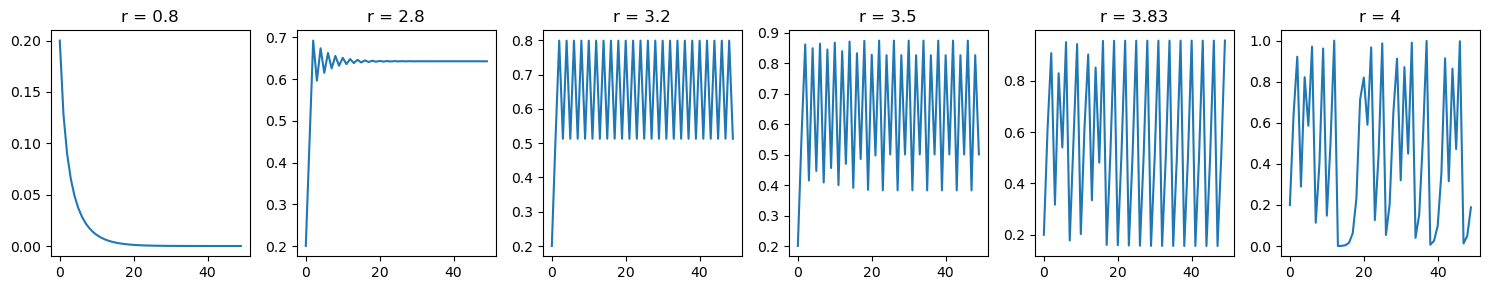

In [200]:
def build_log_orb(r, x0, n, discard_flag, discard_num=400):
    log_orb = np.zeros(n)
    log_orb[0] = x0
    for i in range(1, n):
        log_orb[i] = r*log_orb[i-1]*(1-log_orb[i-1])
    if discard_flag:
        return log_orb[len(log_orb)-400:]
    else:
        return log_orb

rs = [0.8, 2.8, 3.2, 3.5, 3.83, 4]

fig = plt.figure(figsize=(15, 3))

for i in range(0, len(rs)):
    logistic_orbit = build_log_orb(rs[i], 0.2, 5000, False)
    plt.subplot(1, len(rs), i+1)
    plt.plot(logistic_orbit[0:50])
    plt.title(f"r = {rs[i]}")

plt.tight_layout()
plt.show()

Chaos visualisation - two orbits started within negligble distance but become unrelated in a small amount of steps with different rs. Skipping 0s to avoid a -inf result.

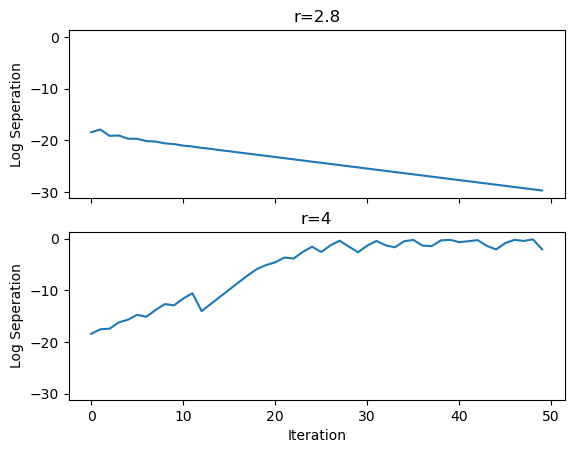

In [201]:
x0_org = 0.2
x0_new = 0.2 + 1e-8

abs_diff1 = np.abs(build_log_orb(2.8, x0_new, 50, False)- build_log_orb(2.8, x0_org, 50, False))
log_abs_diff1 = np.log(abs_diff1, out=np.full_like(abs_diff1, np.nan, dtype=np.float64), where=(abs_diff1!=0))
abs_diff2 = np.abs(build_log_orb(4, x0_new, 50, False)- build_log_orb(4, x0_org, 50, False))
log_abs_diff2 = np.log(abs_diff2, out=np.full_like(abs_diff2, np.nan, dtype=np.float64), where=(abs_diff2!=0))

fig, (ax1, ax2) = plt.subplots(2, sharex=True, sharey=True)
ax1.plot(log_abs_diff1)
ax1.set_title("r=2.8")
ax1.set_ylabel("Log Seperation")

ax2.plot(log_abs_diff2)
ax2.set_title("r=4")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Log Seperation")
plt.show()

Cobweb plot, showing geometrical behaviour of fixed point, how it becomes chaotic or periodic dependent on r

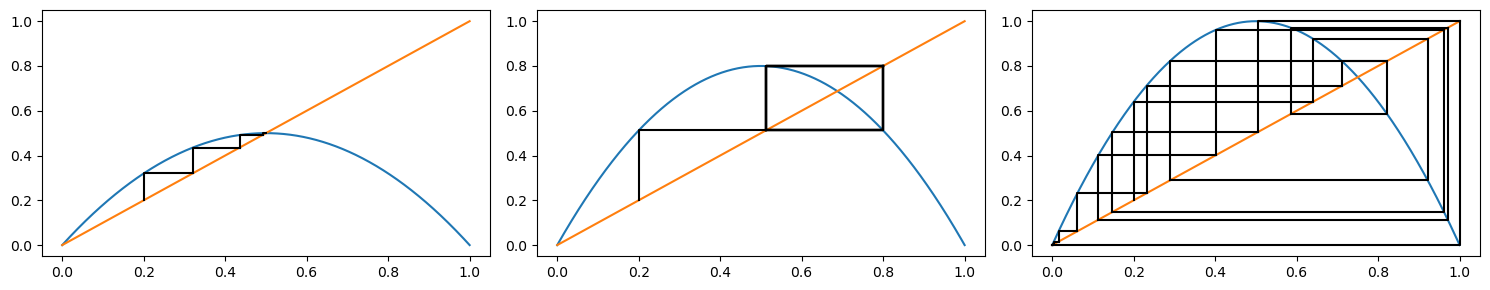

In [202]:
def cobweb_plot(orbit, r, n=20):

    x = np.linspace(0, 1, 1000)
    y = r * x * (1 - x)

    plt.plot(x, y)
    plt.plot(x, x)

    for i in range(n):
        plt.plot(
            [orbit[i], orbit[i], orbit[i+1]],
            [orbit[i], orbit[i+1], orbit[i+1]],
            color="black"
        )

fig = plt.figure(figsize=(15, 3))
rs = [2, 3.2, 4]
for i in range(0,len(rs)):
    logistic_orbit = build_log_orb(rs[i], 0.2, 5000, False)
    plt.subplot(1, len(rs), i+1)
    cobweb_plot(logistic_orbit, rs[i])

plt.tight_layout()
plt.show()

On paper, worked out that fixed point converges to 1 - 1/r by solving f(x) = x, and found that slope at that point is 2-r, differentiating f(x) and substituting the fixed point. Numerical check to see if this works. For the map to attract, the magnitude of the slope of the fixed point must be below 1 therefore r must be between 1 and 3. For convergence and speed sake, we use 1.2 and 2.8 as our bounds

In [203]:
def check_fixed_and_slope(r, fixed_converge, slope_fixed):
    fixed_point = 1 - 1/r
    slope = 2 - r
    if abs(fixed_converge - fixed_point) <= 1e-4 and abs(slope_fixed - slope) <= 1e-4:
        return True
    else:
        return False

def measure_slope(orbit, fixed_converge, lo=1e-12, hi=1e-3):
    # Distance to the fixed point at each step
    err = orbit - fixed_converge    
    
    # consecutive pairs of errors
    num, den = err[1:], err[:-1]     
    mask = (np.abs(den) > lo) & (np.abs(den) < hi) & (np.abs(num) > lo)

    if mask.sum() == 0:
        return np.nan, 0
    return np.median(num[mask] / den[mask])

rs = np.zeros(100)
for i in range(0, len(rs)):
    rs[i] = 1.2 + 1.6*rand.random()

results = []
for r in rs:
    x0 = rand.random()
    logistic_orbit = build_log_orb(r, x0, 1000, False)
    fixed_converge = np.average(logistic_orbit[950:])
    slope = measure_slope(logistic_orbit, fixed_converge)
    results = np.append(results, check_fixed_and_slope(r, fixed_converge, slope))

if all(results):
    print("No Failure")
else:
    print("Error: Numerical Failure")

No Failure


Bifurcation diagram generation

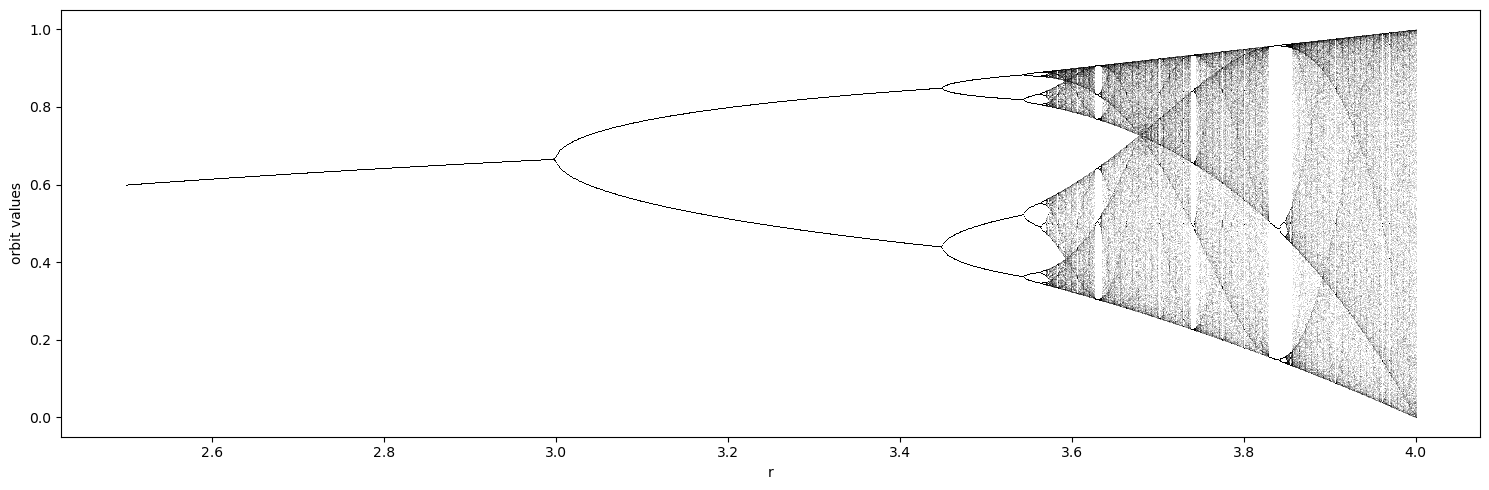

In [204]:
rs = np.linspace(2.5, 4, 1500)
keep = 400

R = []
Y = []
for r in rs:
    # Keep last 1000 vales (periodic part)
    y = build_log_orb(r, 0.4, 1500, True, 500)
    # Repeat this r once per y value (array of r same length as y)
    R.append(np.full(len(y), r))
    Y.append(y)

R = np.concatenate(R)
Y = np.concatenate(Y)

plt.figure(figsize=(15, 5))
plt.scatter(R, Y, s=0.35, alpha=0.49, color="black", marker=".", linewidths=0)
plt.xlabel("r")
plt.ylabel("orbit values")
plt.tight_layout()
plt.show()

Calculate Feigenbaum constant, see if result matches with literature value 4.6692. Start with function g(r) = 0 to find r, and use bisection to solve for r. g(r) is essentially logistic map applied 2^n times, starting at superstable point x=0.5, to find r

In [205]:
def g_of_r(r, p):
    x_prev = 0.5
    x_next = 0
    for i in range(0, p):
        x_next = r * x_prev * (1 - x_prev)
        x_prev = x_next
    return x_next - 0.5


def bisection(p, a, b, tol=1e-12):
    while (b - a) / 2.0 > tol:
        mid = (a + b) / 2.0
        if g_of_r(a, p) * g_of_r(mid, p) <= 0:
            b = mid
        else:
            a = mid
    return (a + b) / 2.0

periods = [1, 2, 4, 8, 16, 32, 64, 128, 256]
r_values = []
start_r = 1.0
step = 1e-4

for p in periods:
    if len(r_values) >= 2:
        step = (r_values[-1] - r_values[-2]) / 100.0

    a = start_r
    current_r = a + step
    b = None

    while current_r <= 4.0:
        if g_of_r(a, p) * g_of_r(current_r, p) <= 0:
            b = current_r
            break
        a = current_r
        current_r += step
        
    if b==None:
            print("Error: no sign change found")
            break
        
    r_val = bisection(p, a, b)
    r_values.append(r_val)
    start_r = r_val + (step / 10.0)

delta = (r_values[-2] - r_values[-3]) / (r_values[-1] - r_values[-2])
print(f"Feigenbaum constant calculated to be: {delta}")
print("Constant cannot be calculated for first two r values/period 1 and 2, as it requires the first 3 r values")
for j in range(3, len(periods)):
    constant = (r_values[j-2] - r_values[j-3]) / (r_values[j-1] - r_values[j-2])
    print(f"Calculated constant at period {periods[j]} = {constant}, with absolute error: {np.absolute(4.66920160910299-constant)}")


Feigenbaum constant calculated to be: 4.66919095504943
Constant cannot be calculated for first two r values/period 1 and 2, as it requires the first 3 r values
Calculated constant at period 8 = 4.70894301353804, with absolute error: 0.039741404435049255
Calculated constant at period 16 = 4.680770998052605, with absolute error: 0.011569388949614456
Calculated constant at period 32 = 4.662959611029411, with absolute error: 0.006241998073579502
Calculated constant at period 64 = 4.6684039247445455, with absolute error: 0.0007976843584449611
Calculated constant at period 128 = 4.668953753503657, with absolute error: 0.00024785559933349077
Calculated constant at period 256 = 4.66915715972743, with absolute error: 4.4449375560695614e-05


Calculate Lyapunov constant as a final analytical check to see existing code is behaving as it is meant to. Aiming to gain constant equal to ln 2 (~0.693147) at r=4. r=4 as its orbit fills the whole interval, and exact answer exists here (logistic map equivalent to tent map)

In [206]:
r = 4
logistic_orbit = build_log_orb(r, 0.2, 100000, False)
diff_logistic_map = lambda r,orb: r*(1-2*orb)
logistic_differential = diff_logistic_map(r, logistic_orbit)
logistic_diff = np.abs(logistic_differential)
# Mask negliglble derivatives to avoid extremely low (tending to -inf) log vals 
lyapunov_constant = np.nanmean(np.log(logistic_diff, out=np.full_like(logistic_diff, np.nan, dtype=np.float64), where=(logistic_diff>1e-12)))
percentage_difference = 100*np.abs((lyapunov_constant-np.log(2))/np.log(2))
print(f"Lyapunov constant calculated to be: {lyapunov_constant}, ln 2: {np.log(2)}, percentage difference between the two: {percentage_difference}")

Lyapunov constant calculated to be: 0.693144405352077, ln 2: 0.6931471805599453, percentage difference between the two: 0.00040037786290159284


Invariant density - seeing how much time does the orbit spend in each part of [0,1]. Invariant as histogram's shape will be the same no matter the starting point. May be an inconsistency as the function blows up at x = 0 and 1. Overlayed with arcsine density arising from tent map conjugacy, as this is a closed form to validate against later. Limited at as of earlier mentioned divergence as x tends to 0 and 1.

Mean absolute difference between histogram bars and closed form for histogram 1: 0.028694978944703724
Mean absolute difference between histogram bars and closed form for histogram 2: 0.028839872413606672
Mean absolute difference between histogram bars and closed form for histogram 3: 0.031080179753634835
Mean absolute difference between histogram bars and closed form for histogram 4: 0.033067986885307626


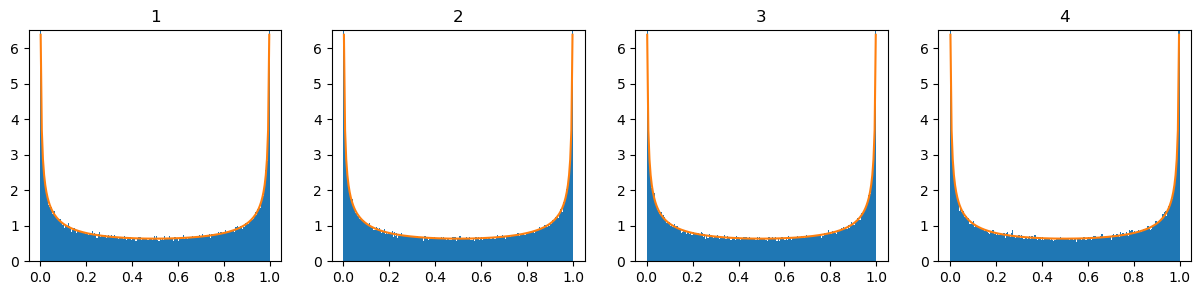

In [207]:
fig = plt.figure(figsize=(15, 3))
# Starting above 0 and ending below 1 to avoid division by 0
centres = np.zeros(200)
for i in range(1,5):
    logistic_orbit = build_log_orb(r, rand.random(), 100000, False)
    ax = fig.add_subplot(1, 4, i)
    heights, edges, _ = ax.hist(logistic_orbit, bins=200, density=True)
    centres = 0.5*(edges[:-1] + edges[1:])
    closed_form = 1/(np.pi*np.sqrt(centres*(1-centres)))
    h = ax.plot(centres, closed_form)
    h = ax.set_ylim(0, 6.5)
    h = ax.set_title(f'{i}')
    # From 20 to 180 to not include divergence results
    height_diffs = np.abs(closed_form[20:180]-heights[20:180])
    print(f"Mean absolute difference between histogram bars and closed form for histogram {i}: {np.mean(height_diffs)}")
plt.show()


Ulam's Method to generate transition matrix, for markov chain creation. Power iteration to find stationary distribution - the probability distribution that does not change when the transition matrix is applied and hence eigenvector associated with dominant eigenvector

Largest row sum deviation from 1: 2.1316282072803006e-14


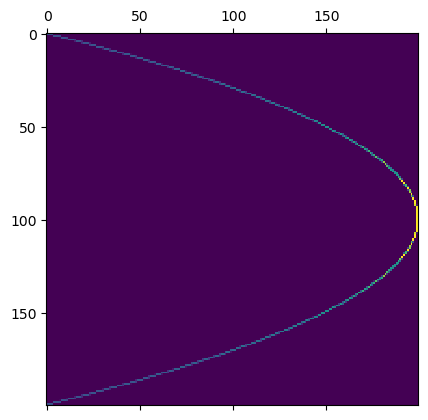

In [208]:
r = 4
num_boxes = 200
logistic_orbit = build_log_orb(r, 0.2, 100000, False)

def exact_ulam_matrix(N):
    edges = np.linspace(0, 1, N+1)
    lo_target, hi_target = edges[:-1], edges[1:]
    # Two inverse branches of f
    sqrt_lo, sqrt_hi = np.sqrt(1 - lo_target), np.sqrt(1 - hi_target)
    left_start, left_end = (1 - sqrt_lo)/2, (1 - sqrt_hi)/2
    right_start, right_end = (1 + sqrt_hi)/2, (1 + sqrt_lo)/2

    transition_temp = np.zeros([N, N])
    for row_num in range(0, N):
        box_start, box_end = edges[row_num], edges[row_num+1]
        # How much of box row_num sits inside each preimage interval
        overlap = np.maximum(0, np.minimum(box_end, left_end) - np.maximum(box_start, left_start))
        overlap += np.maximum(0, np.minimum(box_end, right_end) - np.maximum(box_start, right_start))
        # Divide by box width 1/N to turn a length into a probability
        transition_temp[row_num] = overlap * N
    return transition_temp

def empirical_ulam_matrix(orbit, N):
    boxes = np.clip((orbit*N).astype(int), 0, N-1)
    from_arr, to_arr = boxes[:-1], boxes[1:]
    # Point (i, j) is how many times we go from a point in from_arr to a point in to_arr.
    transition_temp = np.zeros([N, N])
    np.add.at(transition_temp, (from_arr, to_arr), 1)
    row_totals = transition_temp.sum(axis=1)
    if np.any(row_totals == 0):
        print("Error: Invalid row")
        return None
    return transition_temp/row_totals[:, None]

def power_iteration(prev_vec, matrix, tol=1e-10, iteration_cap=2000):
    conv_hist = []
    for iteration_count in range(iteration_cap):
        next_vec = np.matmul(prev_vec, matrix)
        # Normalise to guard against any floating point drift
        next_vec = next_vec/np.sum(next_vec)
        diffs = np.abs(next_vec - prev_vec)
        conv_hist.append(np.sum(diffs))
        if conv_hist[-1] < tol:
            return next_vec, conv_hist
        prev_vec = next_vec
    print("Error: did not converge")
    return next_vec, conv_hist

transition_matrix = exact_ulam_matrix(num_boxes)
print(f"Largest row sum deviation from 1: {np.max(np.abs(np.sum(transition_matrix, axis=1) - 1))}")
plt.matshow(transition_matrix)

Final vectors are equal (T/F): True
Largest difference between orbit stationary vector and occupancy histogram: 9.72391236257926e-06


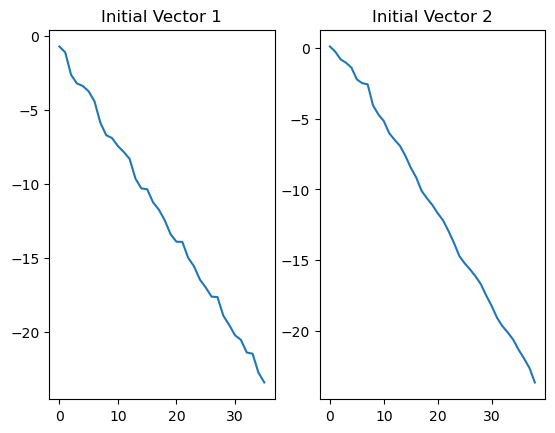

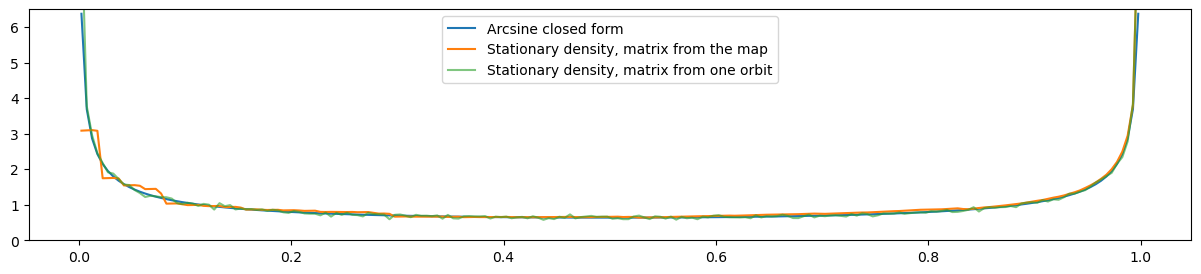

Mean absolute difference between stationary vector and closed form: 0.03312610627634023


In [209]:
initial_vec1 = np.zeros(num_boxes) + 1/num_boxes
final_vector1, history1 = power_iteration(initial_vec1, transition_matrix)

initial_vec2 = np.random.dirichlet(np.ones(num_boxes))
final_vector2, history2 = power_iteration(initial_vec2, transition_matrix)
print(f"Final vectors are equal (T/F): {np.sum(np.abs(final_vector1 - final_vector2)) < 1e-8}")
plt.subplot(1, 2, 1)
plt.title("Initial Vector 1")
plt.plot(np.log(history1))
plt.subplot(1, 2, 2)
plt.title("Initial Vector 2")
plt.plot(np.log(history2))

# Same method but with the matrix counted off a single orbit, for comparison
orbit_matrix = empirical_ulam_matrix(logistic_orbit, num_boxes)
orbit_vector, orbit_history = power_iteration(initial_vec1, orbit_matrix)

# The orbit built chain is stationary at its own occupancy histogram
boxes = np.clip((logistic_orbit*num_boxes).astype(int), 0, num_boxes-1)
occupancy = np.bincount(boxes, minlength=num_boxes)/len(logistic_orbit)
print(f"Largest difference between orbit stationary vector and occupancy histogram: {np.max(np.abs(orbit_vector - occupancy))}")

edges = np.linspace(0, 1, num_boxes + 1)
stationary_vector = final_vector1 * num_boxes
orbit_density = orbit_vector * num_boxes
fig = plt.figure(figsize=(15, 3))
centres = 0.5*(edges[:-1] + edges[1:])
closed_form = 1/(np.pi*np.sqrt(centres*(1-centres)))
plt.plot(centres, closed_form, label="Arcsine closed form")
plt.plot(centres, stationary_vector, label="Stationary density, matrix from the map")
plt.plot(centres, orbit_density, label="Stationary density, matrix from one orbit", alpha=0.6)
plt.ylim([0, 6.5])
plt.legend()
plt.show()
height_diffs = np.abs(closed_form[20:180]-stationary_vector[20:180])
print(f"Mean absolute difference between stationary vector and closed form: {np.mean(height_diffs)}")

Measure how error in Markov approximation changes as boxes become smaller.

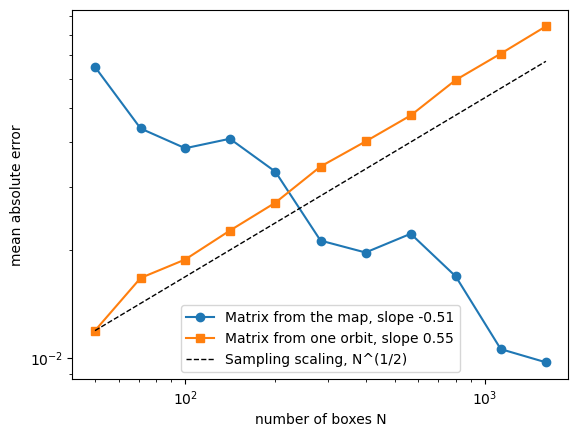

Slope, matrix from the map: -0.5090329333968932
Slope, matrix from one orbit: 0.5485222653211931


In [210]:
def density_error(stationary_vec, N, frac=0.1):
    density = stationary_vec * N
    centres = (np.arange(N) + 0.5) / N
    exact = 1/(np.pi*np.sqrt(centres*(1-centres)))
    # Trim the outer frac at each end, where the closed form diverges
    lo, hi = int(frac*N), int((1-frac)*N)
    return np.mean(np.abs(density[lo:hi] - exact[lo:hi]))

Ns = [50, 71, 100, 141, 200, 283, 400, 566, 800, 1131, 1600]
errs_map = []
errs_orbit = []
for N in Ns:
    map_vec = power_iteration(np.zeros(N) + 1/N, exact_ulam_matrix(N))[0]
    errs_map.append(density_error(map_vec, N))
    orbit_vec = power_iteration(np.zeros(N) + 1/N, empirical_ulam_matrix(logistic_orbit, N))[0]
    errs_orbit.append(density_error(orbit_vec, N))

slope_map = np.polyfit(np.log(Ns), np.log(errs_map), 1)[0]
slope_orbit = np.polyfit(np.log(Ns), np.log(errs_orbit), 1)[0]
sampling_line = errs_orbit[0]*np.sqrt(np.array(Ns)/Ns[0])
plt.loglog(Ns, errs_map, "o-", label=f"Matrix from the map, slope {slope_map:.2f}")
plt.loglog(Ns, errs_orbit, "s-", label=f"Matrix from one orbit, slope {slope_orbit:.2f}")
plt.loglog(Ns, sampling_line, "k--", linewidth=1, label="Sampling scaling, N^(1/2)")
plt.xlabel("number of boxes N"); plt.ylabel("mean absolute error")
plt.legend()
plt.show()
print(f"Slope, matrix from the map: {slope_map}")
print(f"Slope, matrix from one orbit: {slope_orbit}")